# Readout quickstart

This notebook builds two small, independent readout examples from public TensorDSLab pieces. The numbers are illustrative. Application packages usually provide their own axes, kernels, and workflow wrappers.

We begin with Torch, Matplotlib, and the public TensorCore and TensorDSLab objects used below.

In [1]:
import math

import matplotlib.pyplot as plt
import torch

from tensor_core import (
    CountCoordinates,
    LabelCoordinates,
    NonnegativeInteger,
    OffsetAxis,
    OffsetCoordinates,
    RegularCoordinates,
    Threefry4x32,
)

from tensor_dslab import (
    AnalogGain,
    AnalogGainSpec,
    AnalogWaveform,
    AnalogWaveformConfig,
    AnalogWaveformKernels,
    AnalogWaveformSpec,
    BitDepth,
    BitDepthSpec,
    ChannelAxis,
    Charge,
    ChargeConfig,
    ChargeKernels,
    ChargeSpec,
    DelayedCrosstalk,
    DelayedCrosstalkSpec,
    DigitizedWaveform,
    DigitizedWaveformConfig,
    DigitizedWaveformKernels,
    DigitizedWaveformSpec,
    EncodedWaveform,
    EncodedWaveformConfig,
    EncodedWaveformKernels,
    EncodedWaveformSpec,
    ExampleAxis,
    FrequencyAxis,
    InputMaximum,
    InputMaximumSpec,
    InputMinimum,
    InputMinimumSpec,
    NoiseWaveform,
    NoiseWaveformConfig,
    NoiseWaveformKernels,
    NoiseWaveformSpec,
    Photoelectrons,
    PhotoelectronsSpec,
    PostTriggerSamples,
    PostTriggerSamplesSpec,
    PowerSpectralDensity,
    PowerSpectralDensitySpec,
    PreTriggerSamples,
    PreTriggerSamplesSpec,
    PulseResponse,
    PulseResponseSpec,
    PureWaveform,
    PureWaveformConfig,
    PureWaveformKernels,
    PureWaveformSpec,
    ReleaseThresholdCode,
    ReleaseThresholdCodeSpec,
    RequiredTimeOverSamples,
    RequiredTimeOverSamplesSpec,
    TimeAxis,
    TriggerThresholdCode,
    TriggerThresholdCodeSpec,
    unit_registry,
)

Before constructing a Product, an Example axis batches two independent waveform realizations, the Channel axis names three sensors, and the Time axis gives the last tensor dimension a physical spacing. One Product call processes the complete tensor across both examples and all three sensors. Every Product below uses this same ordered domain. The Frequency axis describes the global PSD bins used during preparation; it is not a Product dimension.

In [2]:
device = torch.device("cpu")
field_dtype = torch.float32

example_axis = ExampleAxis(
    coordinates=CountCoordinates(count=2),
)

channel_axis = ChannelAxis(
    coordinates=LabelCoordinates(
        labels=("sensor-0", "sensor-1", "sensor-2"),
    ),
)

time_axis = TimeAxis(
    coordinates=RegularCoordinates(
        start=0,
        step=1,
        count=5000,
    ),
    coordinate_scale=2.0,
    unit=unit_registry.Unit("ns"),
)

frequency_axis = FrequencyAxis(
    coordinates=RegularCoordinates(
        start=0,
        step=1,
        count=2501,
    ),
    coordinate_scale=0.1,
    unit=unit_registry.Unit("MHz"),
)

axes = (
    example_axis,
    channel_axis,
    time_axis,
)

A small presentation-only helper keeps the seven Product grids consistent. Each figure uses columns for the two independent examples and rows for the three sensors, so every subplot corresponds to one exact `(example, channel)` lane. A Product keeps one color across all six lanes. Titles and row labels make legends unnecessary, and the helper never constructs or changes a Product.

In [3]:
plt.style.use("seaborn-v0_8-whitegrid")

channel_labels = channel_axis.coordinates.labels
time_ns = [
    float(time_axis.quantity_at(index).to("ns").magnitude)
    for index in range(time_axis.size)
]
product_figures = []


def plot_product(
    product,
    *,
    title,
    color,
    step,
    suppression_code=None,
):
    figure, plot_axes = plt.subplots(
        3,
        2,
        figsize=(13, 8.5),
        sharex=True,
        squeeze=False,
    )
    for channel_index, channel_label in enumerate(channel_labels):
        for example_index in range(example_axis.size):
            plot_axis = plot_axes[channel_index, example_index]
            values = (
                product.tensor[example_index, channel_index]
                .detach()
                .cpu()
                .tolist()
            )
            if suppression_code is not None:
                values = [
                    float("nan") if value == suppression_code else value
                    for value in values
                ]
            if step:
                plot_axis.step(
                    time_ns,
                    values,
                    where="post",
                    color=color,
                    alpha=0.72,
                    linewidth=0.9,
                )
            else:
                plot_axis.plot(
                    time_ns,
                    values,
                    color=color,
                    alpha=0.72,
                    linewidth=0.9,
                )
            if channel_index == 0:
                plot_axis.set_title(f"Example {example_index}")
            if example_index == 0:
                plot_axis.set_ylabel(channel_label)
            if channel_index == channel_axis.size - 1:
                plot_axis.set_xlabel("Time (ns)")
    figure.suptitle(title)
    figure.subplots_adjust(
        left=0.08,
        right=0.98,
        bottom=0.08,
        top=0.91,
        hspace=0.18,
        wspace=0.12,
    )
    product_figures.append(figure)
    plt.show()

First we prepare the source counts as an ordinary integer tensor. Example 0 has four deposits, while Example 1 uses four different deposits across the same three sensors. The two examples are independent waveform realizations from different data sources, such as two G4 simulations with different RNG seeds. They are not adjacent windows or sequential state.

In [4]:
photoelectron_values = torch.zeros(
    tuple(axis.size for axis in axes),
    dtype=torch.int64,
    device=device,
)
photoelectron_values[0, 0, 100] = 1
photoelectron_values[0, 0, 3700] = 4
photoelectron_values[0, 1, 1300] = 2
photoelectron_values[0, 2, 2500] = 3
photoelectron_values[1, 0, 800] = 2
photoelectron_values[1, 1, 2000] = 4
photoelectron_values[1, 1, 3500] = 1
photoelectron_values[1, 2, 2900] = 3
photoelectron_values_before = photoelectron_values.clone()

## Photoelectrons

The semantic layer names the tensor's axes, device, dtype, and avalanche unit. One `Photoelectrons` Product holds both independent examples and all three sensors in one tensor.

In [5]:
photoelectrons_spec = PhotoelectronsSpec(
    axes=axes,
    device=device,
    dtype=torch.int64,
    unit=unit_registry.Unit("avalanche"),
)

photoelectrons = Photoelectrons(
    tensor=photoelectron_values,
    spec=photoelectrons_spec,
)

The first local grid shows each example and sensor lane separately, including all eight sparse source deposits.

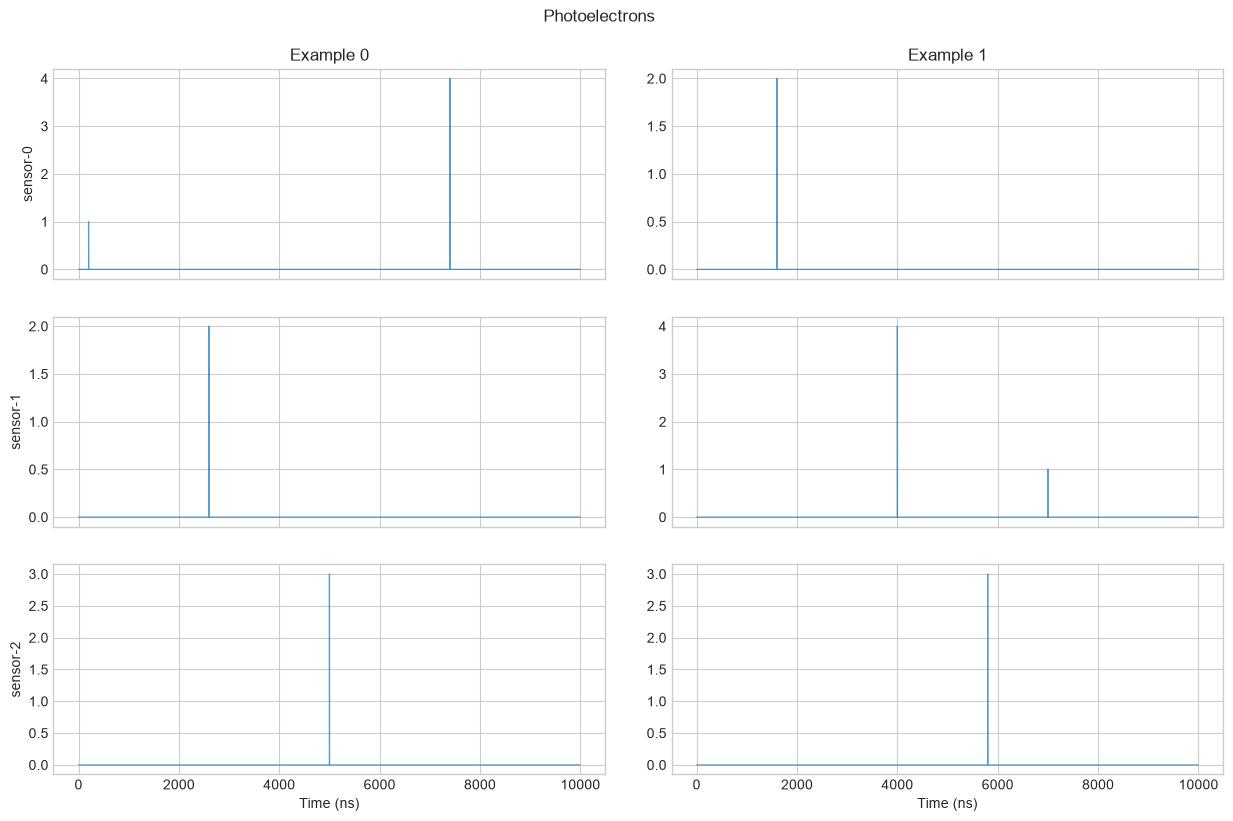

In [6]:
plot_product(
    photoelectrons,
    title="Photoelectrons",
    color="tab:blue",
    step=True,
)

## Charge

The `Charge` Product simulates avalanche effects inside the SiPMs. To illustrate this point, we add one delayed-crosstalk law shared by every example and sensor. Its coefficients describe expected Poisson offspring at later sample offsets for each avalanche inside a sensor.

In [7]:
delayed_offsets = tuple(range(1, 251))
delayed_times_ns = (
    torch.arange(
        1,
        251,
        dtype=torch.float64,
        device=device,
    )
    * time_axis.coordinate_scale
)
delayed_crosstalk_values = torch.exp(
    -delayed_times_ns / 150.0
)
delayed_crosstalk_values *= (
    0.15 / delayed_crosstalk_values.sum()
)

The prepared vector now receives one Time-relative `OffsetAxis` and an unconditioned `DelayedCrosstalkSpec`, so the same expected-offspring law applies to every example and sensor. In `ChargeConfig`, we specify that we want to simulate delayed crosstalk for two generations. The same `DelayedCrosstalk` Kernel applies to all six lanes, but TensorDSLab's addressed RNG keeps the stochastic realizations independent.

In [8]:
delayed_time_axis = OffsetAxis(
    coordinates=OffsetCoordinates(
        offsets=delayed_offsets,
    ),
    relative_to=TimeAxis,
)

delayed_crosstalk = DelayedCrosstalk(
    tensor=delayed_crosstalk_values,
    spec=DelayedCrosstalkSpec(
        conditioning_axes=(),
        operation_axes=(delayed_time_axis,),
        device=device,
        dtype=torch.float64,
        unit=unit_registry.Unit(""),
    ),
)

charge_spec = ChargeSpec(
    axes=axes,
    device=device,
    dtype=field_dtype,
    unit=unit_registry.Unit("avalanche"),
)

charge_config = ChargeConfig(
    spec=charge_spec,
    kernels=ChargeKernels(
        members=(delayed_crosstalk,),
    ),
    correlated_avalanche_generations=NonnegativeInteger(value=2),
)

rng = Threefry4x32(seed=2026)

charge = Charge.create(
    sources=(photoelectrons,),
    config=charge_config,
    rng=rng,
)

When we plot `Charge`, we can see the additional delayed avalanches.

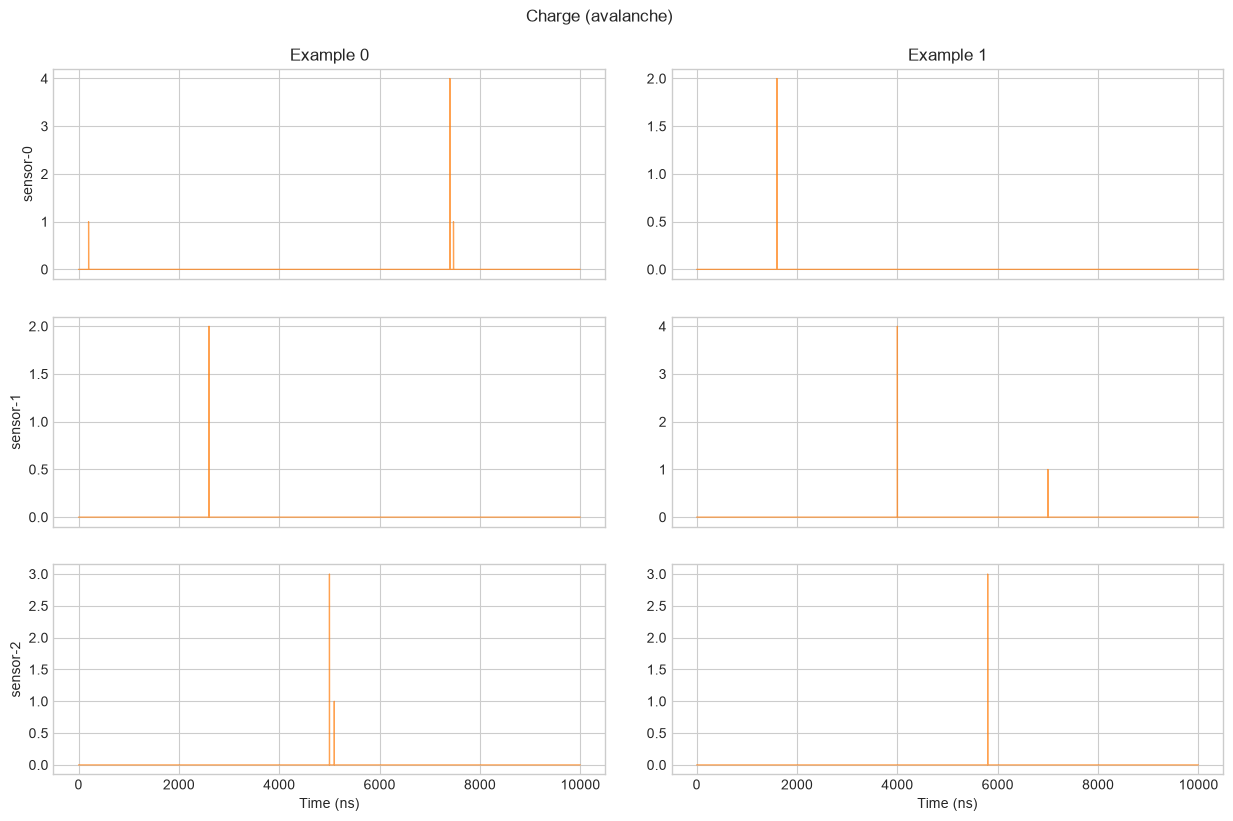

In [9]:
plot_product(
    charge,
    title="Charge (avalanche)",
    color="tab:orange",
    step=True,
)

## PureWaveform

An illustrative 2,020.27 ns pulse response is prepared from a Gaussian and two error functions. The response is illustrative rather than calibrated.

In [10]:
pulse_support_ns = 2020.27
pulse_coefficient_count = math.ceil(
    pulse_support_ns / time_axis.coordinate_scale
)
pulse_offsets = torch.arange(
    pulse_coefficient_count,
    dtype=field_dtype,
    device=device,
)
pulse_time_ns = pulse_offsets * time_axis.coordinate_scale
pulse_x = pulse_time_ns - 232.89

pulse_gaussian = torch.exp(
    -(pulse_x**2) / (2.0 * 507.72**2)
) / math.sqrt(2.0 * math.pi * 507.72**2)
pulse_first = 1.0 + torch.erf(
    (pulse_x - (-81.92)) / (math.sqrt(2.0) * 147.28)
)
pulse_second = 1.0 + torch.erf(
    (pulse_x - (-176.50)) / (math.sqrt(2.0) * 45.69)
)

pulse_raw = pulse_gaussian * pulse_first * pulse_second
pulse_values = (
    pulse_raw / torch.max(torch.abs(pulse_raw)) * -14.5912372
)

We prepare these values as a `PulseResponse` Kernel, declaring the Time-relative operation axis used when `PureWaveform` convolves `Charge` with the response. With no conditioning axes in the `PulseResponseSpec`, every example and channel shares the same pulse response.

In [11]:
pulse_time_axis = OffsetAxis(
    coordinates=OffsetCoordinates(offsets=tuple(range(1011))),
    relative_to=TimeAxis,
)

pulse_response = PulseResponse(
    tensor=pulse_values,
    spec=PulseResponseSpec(
        conditioning_axes=(),
        operation_axes=(pulse_time_axis,),
        device=device,
        dtype=field_dtype,
        unit=unit_registry.Unit("mV / avalanche"),
    ),
)

pure_waveform_config = PureWaveformConfig(
    spec=PureWaveformSpec(
        axes=axes,
        device=device,
        dtype=field_dtype,
        unit=unit_registry.Unit("mV"),
    ),
    kernels=PureWaveformKernels(
        members=(pulse_response,),
    ),
)

pure_waveform = PureWaveform.create(
    sources=(charge,),
    config=pure_waveform_config,
)

`PureWaveform` convolves `Charge` with `PulseResponse`, turning each avalanche into a negative-going pulse.

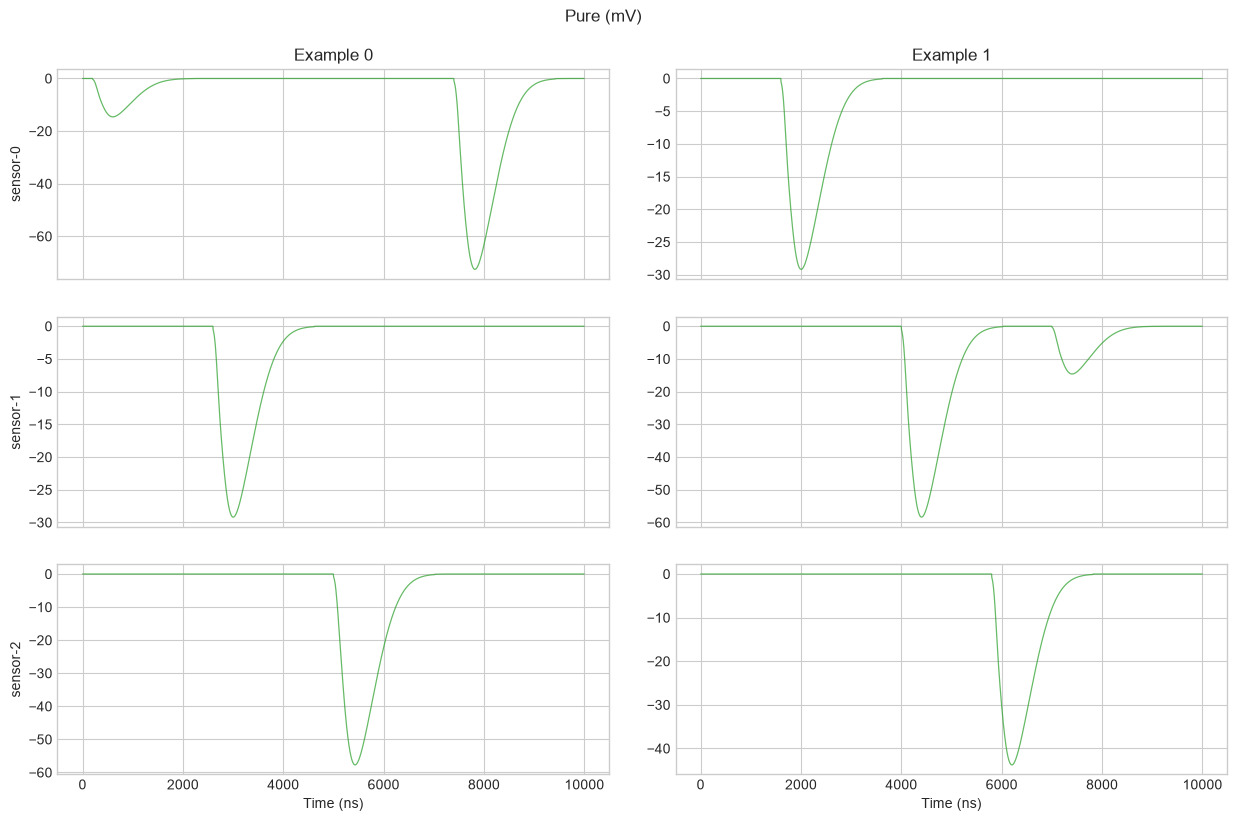

In [12]:
plot_product(
    pure_waveform,
    title="Pure (mV)",
    color="tab:green",
    step=False,
)

## NoiseWaveform

We prepare values for a typical sensor's power spectral density (PSD) to be used by all examples and sensors; TensorDSLab's RNG addressing makes all realizations of PSD noise independently stochastic.

In [13]:
psd_values = torch.cat(
    (
        torch.tensor(
            (
0, 0.364616364, 0.718572736, 1.06998181, 1.21785772, 1.16758037, 1.03646076, 0.865753114,
    0.714446306, 0.604379117, 0.487569302, 0.40951094, 0.337632418, 0.286891967, 0.243240327, 0.2040672,
    0.182289213, 0.150123388, 0.131426826, 0.111578815, 0.0958504602, 0.0847055167, 0.0728473514, 0.0636719391,
    0.0562573262, 0.0493672676, 0.0438943021, 0.0392317213, 0.0346784666, 0.0306321196, 0.0280252565, 0.024939796,
    0.0223720614, 0.0206092857, 0.0180705804, 0.0166453589, 0.0146423597, 0.0134249022, 0.0123853059, 0.0113443006,
    0.0103526218, 0.00946519617, 0.00860434212, 0.00786234997, 0.00720287301, 0.00662884535, 0.006200328, 0.00567184994,
    0.00528546516, 0.00487921014, 0.00451319804, 0.00433120597, 0.0040281429, 0.00372205884, 0.00353176915, 0.0032562064,
    0.00306412997, 0.00286466838, 0.00266614626, 0.00251337257, 0.0023917798, 0.00224566925, 0.00208947714, 0.00199150061,
    0.00183371257, 0.00176880055, 0.00166656275, 0.00156063982, 0.00148656638, 0.00142843241, 0.00136238849, 0.00130025169,
    0.00124088663, 0.00114957127, 0.00111110148, 0.00106265454, 0.00100224616, 0.000956447562, 0.000898769475, 0.000880464795,
    0.000822985487, 0.000792701088, 0.000771020364, 0.000742893026, 0.000715292583, 0.000686455227, 0.000652796531, 0.000626438588,
    0.000613452052, 0.00057131052, 0.000566459959, 0.000537940126, 0.000531699858, 0.000509422389, 0.000490178878, 0.000477399357,
    0.000457925256, 0.000432383327, 0.000422302575, 0.000424339727, 0.000402010104, 0.000391152309, 0.00037535833, 0.000365524465,
    0.000364027132, 0.000351159048, 0.000332970143, 0.000323985121, 0.00032642798, 0.000308569579, 0.00030073995, 0.0002924531,
    0.000283862028, 0.000276971434, 0.000278932159, 0.000265044044, 0.000254971441, 0.000252293481, 0.000245081465, 0.000241413742,
    0.000237936634, 0.000227258381, 0.000226814271, 0.000223529889, 0.000223200332, 0.000212757062, 0.000210065497, 0.000205305099,
    0.000202584022, 0.000194579479, 0.000193051659, 0.000192905354, 0.000188797145, 0.000182486328, 0.000184201781, 0.000176634974,
    0.000172617612, 0.000171031003, 0.000166015889, 0.00016719909, 0.000161563425, 0.000161533433, 0.000156585083, 0.000155668444,
    0.000149000683, 0.000150794367, 0.000149306303, 0.000146653707, 0.000145005688, 0.000144144578, 0.000144359525, 0.000139302239,
    0.000137446157, 0.000135975788, 0.000135313167, 0.000131797351, 0.00013092802, 0.000128228945, 0.000125727878, 0.000125753388,
    0.000123524733, 0.00012323822, 0.000123419028, 0.000121052733, 0.000116754141, 0.000120255543, 0.000118534103, 0.000116091091,
    0.000113095688, 0.000112105772, 0.000112316753, 0.00011051583, 0.000110714434, 0.000111751724, 0.000109549692, 0.000107690597,
    0.000106669562, 0.000105452324, 0.000103826736, 0.000103980521, 0.000103737693, 0.00010289206, 0.000101389327, 0.000101903694,
    9.94354559e-05, 9.97896568e-05, 9.90750559e-05, 9.94243237e-05, 9.67564993e-05, 9.56118092e-05, 9.66784282e-05, 9.71639893e-05,
    9.47533772e-05, 9.48382949e-05, 9.41921971e-05, 9.55450305e-05, 9.22495601e-05, 9.21022875e-05, 9.44279454e-05, 9.01232779e-05,
    9.12938413e-05, 9.06712521e-05, 9.04390545e-05, 9.11062598e-05, 8.82836393e-05, 8.96785423e-05, 8.98140934e-05, 8.81974192e-05,
    8.88330542e-05, 8.84958063e-05, 8.77830389e-05, 8.73976096e-05, 8.85152331e-05, 8.80651496e-05, 8.8963061e-05, 8.74032194e-05,
    8.57922641e-05, 8.69337382e-05, 8.61041117e-05, 8.59452339e-05, 8.45852046e-05, 8.42329318e-05, 8.56853585e-05, 8.5304142e-05,
    8.40626089e-05, 8.50940269e-05, 8.35768587e-05, 8.25982061e-05, 8.3204759e-05, 8.21093563e-05, 8.21658832e-05, 8.23311129e-05,
    8.3052073e-05, 8.06010285e-05, 8.2394894e-05, 8.36808904e-05, 8.12596772e-05, 8.14778614e-05, 8.22613001e-05, 8.0863043e-05,
    8.08810946e-05, 7.94198131e-05, 7.81356648e-05, 8.09705816e-05, 8.05111413e-05, 8.00102061e-05, 7.90500198e-05, 8.07041361e-05,
    8.01011192e-05, 7.99121117e-05, 7.910766e-05, 7.86272867e-05, 7.96457316e-05, 7.89338083e-05, 7.84379372e-05, 7.88185207e-05,
    7.90931954e-05, 7.77263995e-05, 7.78386311e-05, 7.78414615e-05, 7.67072052e-05, 7.76013112e-05, 7.79083566e-05, 7.73164866e-05,
    7.74022337e-05, 7.74237415e-05, 7.67269157e-05, 7.75353328e-05, 7.59524701e-05, 7.68596219e-05, 7.58936585e-05, 7.5670876e-05,
    7.62673444e-05, 7.55601941e-05, 7.6056509e-05, 7.60988114e-05, 7.63154094e-05, 7.65029472e-05, 7.63971184e-05, 7.52207779e-05,
    7.2935778e-05, 7.51733678e-05, 7.5656244e-05, 7.39613388e-05, 7.54669381e-05, 7.53413697e-05, 7.35887588e-05, 7.51633052e-05,
    7.55039364e-05, 7.50569016e-05, 7.52226842e-05, 7.38080926e-05, 7.27284059e-05, 7.23675912e-05, 7.39230309e-05, 7.32861881e-05,
    7.29199892e-05, 7.3070034e-05, 7.34977584e-05, 7.31987529e-05, 7.35369686e-05, 7.31417313e-05, 7.21949691e-05, 7.32559929e-05,
    7.33353445e-05, 7.23300545e-05, 7.36164729e-05, 7.21166725e-05, 7.2982577e-05, 7.06133578e-05, 7.33151246e-05, 7.1915696e-05,
    7.18512019e-05, 7.23658959e-05, 7.24778511e-05, 7.17602961e-05, 7.16039358e-05, 7.18727315e-05, 7.13292684e-05, 7.15787173e-05,
    7.05336715e-05, 7.04621634e-05, 7.23114281e-05, 7.10719032e-05, 7.17772782e-05, 7.02244433e-05, 6.93765978e-05, 7.13032714e-05,
    7.1139606e-05, 7.07654326e-05, 6.98905933e-05, 7.11153698e-05, 7.18829979e-05, 6.86865242e-05, 7.02458492e-05, 6.94897972e-05,
    6.87059073e-05, 6.98146541e-05, 6.88052751e-05, 6.92950052e-05, 6.93278198e-05, 7.10806416e-05, 6.82544487e-05, 6.84364059e-05,
    7.03255864e-05, 6.94036426e-05, 6.93348411e-05, 6.88205691e-05, 7.01199097e-05, 6.86530038e-05, 6.83335893e-05, 6.87172942e-05,
    6.85146078e-05, 6.8106463e-05, 6.94013579e-05, 6.7788329e-05, 6.97846335e-05, 6.92315298e-05, 6.7744746e-05, 6.68553766e-05,
    6.81310048e-05, 6.64309409e-05, 6.68983412e-05, 6.87975917e-05, 6.66610722e-05, 6.67555069e-05, 6.77090065e-05, 6.62910461e-05,
    6.59834404e-05, 6.71574599e-05, 6.60670848e-05, 6.62388848e-05, 6.79177101e-05, 6.69508154e-05, 6.70427326e-05, 6.61952363e-05,
    6.65294137e-05, 6.60449514e-05, 6.63777464e-05, 6.61610902e-05, 6.54953255e-05, 6.53387979e-05, 6.71983216e-05, 6.66355263e-05,
    6.4159256e-05, 6.68028733e-05, 6.64693071e-05, 6.69201618e-05, 6.54084361e-05, 6.52104281e-05, 6.60806181e-05, 6.58564459e-05,
    6.50617949e-05, 6.43467647e-05, 6.47386914e-05, 6.44763495e-05, 6.53398383e-05, 6.48394343e-05, 6.54308169e-05, 6.42960149e-05,
    6.42993327e-05, 6.38802958e-05, 6.49643553e-05, 6.45632826e-05, 6.41232473e-05, 6.40789804e-05, 6.41721927e-05, 6.48988425e-05,
    6.40263243e-05, 6.40166181e-05, 6.37204066e-05, 6.46510016e-05, 6.4976477e-05, 6.36221594e-05, 6.39013524e-05, 6.41453444e-05,
    6.27503541e-05, 6.40494982e-05, 6.37843186e-05, 6.52342933e-05, 6.37311314e-05, 6.34668977e-05, 6.4218053e-05, 6.46546396e-05,
    6.31493749e-05, 6.22478619e-05, 6.28140988e-05, 6.34583048e-05, 6.26480469e-05, 6.2671199e-05, 6.34598546e-05, 6.25779576e-05,
    6.22525622e-05, 6.32499577e-05, 6.1954488e-05, 6.2541425e-05, 6.26429028e-05, 6.18028353e-05, 6.20314822e-05, 6.16926409e-05,
    6.32166484e-05, 6.13997909e-05, 6.21030194e-05, 6.13993689e-05, 6.2840285e-05, 6.3649044e-05, 6.23463638e-05, 6.21110376e-05,
    6.05758796e-05, 6.16323159e-05, 6.13966695e-05, 6.27082773e-05, 6.07748625e-05, 6.18182894e-05, 6.13711018e-05, 6.17743863e-05,
    6.21935469e-05, 6.017751e-05, 6.31946386e-05, 6.21715808e-05, 6.09567978e-05, 6.07389702e-05, 6.14102028e-05, 5.95287675e-05,
    6.06575595e-05, 6.24631139e-05, 6.0391445e-05, 6.10238094e-05, 6.11530122e-05, 6.12862568e-05, 6.1038183e-05, 5.97733815e-05,
    6.1582381e-05, 5.95277343e-05, 6.11566793e-05, 5.99573104e-05, 6.12499207e-05, 6.15646277e-05, 6.11720752e-05, 6.07736511e-05,
    5.93497425e-05, 6.1319588e-05, 6.02448854e-05, 6.132204e-05, 6.03522931e-05, 5.8784226e-05, 6.03993103e-05, 6.04307024e-05,
    6.03308945e-05, 5.94356316e-05, 5.99899067e-05, 6.09677081e-05, 6.07043985e-05, 5.94183693e-05, 5.96002683e-05, 6.03224689e-05,
    5.95772071e-05, 5.94694611e-05, 5.99325467e-05, 6.02152613e-05, 5.95092679e-05, 5.91907701e-05, 6.02772343e-05, 5.95585407e-05,
    5.837969e-05, 5.93139484e-05, 5.92181495e-05, 6.08467672e-05, 5.98044389e-05, 5.92738579e-05, 5.92393153e-05, 5.92777178e-05,
    6.01104184e-05, 5.92206343e-05, 5.9673228e-05, 5.86535571e-05, 5.99933119e-05, 5.87774011e-05, 6.04789093e-05, 5.8414942e-05,
    5.87501672e-05, 5.96718783e-05, 6.00966559e-05, 5.96529171e-05, 6.0164075e-05, 5.95980564e-05, 5.96459831e-05, 5.92614924e-05,
    6.02733198e-05, 5.8649508e-05, 5.99001032e-05, 5.93087898e-05, 5.81255263e-05, 5.97312865e-05, 5.80793931e-05, 5.92969955e-05,
    5.87271024e-05, 5.83687906e-05, 5.91362659e-05, 5.86123024e-05, 5.89112133e-05, 6.01479042e-05, 5.9259266e-05, 5.93709519e-05,
    5.77565734e-05, 5.91727694e-05, 5.91755597e-05, 5.77612118e-05, 5.82468201e-05, 5.81608729e-05, 5.88323492e-05, 5.84326081e-05,
    5.86561291e-05, 5.90237905e-05, 5.85095331e-05, 5.80490305e-05, 5.90682903e-05, 5.84991722e-05, 5.84450099e-05, 5.82914727e-05,
    5.80848173e-05, 5.84166446e-05, 5.93956902e-05, 5.75929444e-05, 5.88224175e-05, 5.80825254e-05, 5.76939347e-05, 5.90530617e-05,
    5.7401081e-05, 5.81708337e-05, 5.9085909e-05, 5.82702596e-05, 5.9168422e-05, 5.89404044e-05, 5.79487969e-05, 5.88192343e-05,
    5.75766426e-05, 5.75051163e-05, 5.89908268e-05, 5.83962101e-05, 5.73814068e-05, 5.87736249e-05, 5.85197922e-05, 5.94509438e-05,
    5.85776979e-05, 5.87846771e-05, 5.74095138e-05, 5.82172943e-05, 5.81613021e-05, 5.74073056e-05, 6.11981377e-05, 5.95780548e-05,
    5.89207884e-05, 5.77109313e-05, 5.8583526e-05, 5.92301622e-05, 5.83075707e-05, 5.89152987e-05, 5.83432884e-05, 5.84532972e-05,
    5.86015121e-05, 5.73350007e-05, 5.85755079e-05, 5.85164707e-05, 6.00066051e-05, 6.12808944e-05, 5.74933038e-05, 5.88093935e-05,
    5.88459552e-05, 5.95823367e-05, 6.05022615e-05, 6.19480707e-05, 5.87855793e-05, 5.96374448e-05, 5.9806971e-05, 6.05543028e-05,
    5.96182945e-05, 6.03074732e-05, 6.05987261e-05, 6.13699885e-05, 6.00375861e-05, 6.13428929e-05, 6.24421373e-05, 6.13314187e-05,
    6.31780786e-05, 0.000131492343
            ),
            dtype=field_dtype,
            device=device,
        ),
        torch.zeros(
            frequency_axis.size - 626,
            dtype=field_dtype,
            device=device,
        ),
    )
)

`PowerSpectralDensitySpec` gives the unconditioned PSD Kernel a `FrequencyAxis`. Then, `NoiseWaveform` uses the prepared `PowerSpectralDensity` Kernel to simulate each sensor's electronics noise.

In [14]:
psd_spec = PowerSpectralDensitySpec(
    conditioning_axes=(),
    operation_axes=(frequency_axis,),
    device=device,
    dtype=field_dtype,
    unit=unit_registry.Unit("mV ** 2"),
)

power_spectral_density = PowerSpectralDensity(
    tensor=psd_values,
    spec=psd_spec,
)

noise_waveform_config = NoiseWaveformConfig(
    spec=NoiseWaveformSpec(
        axes=axes,
        device=device,
        dtype=field_dtype,
        unit=unit_registry.Unit("mV"),
    ),
    kernels=NoiseWaveformKernels(
        members=(power_spectral_density,),
    ),
)

noise_waveform = NoiseWaveform.create(
    sources=(),
    config=noise_waveform_config,
    rng=rng,
)

Even though all sensors and examples use the same `PowerSpectralDensity` Kernel, the prepared noise waveforms are independent.

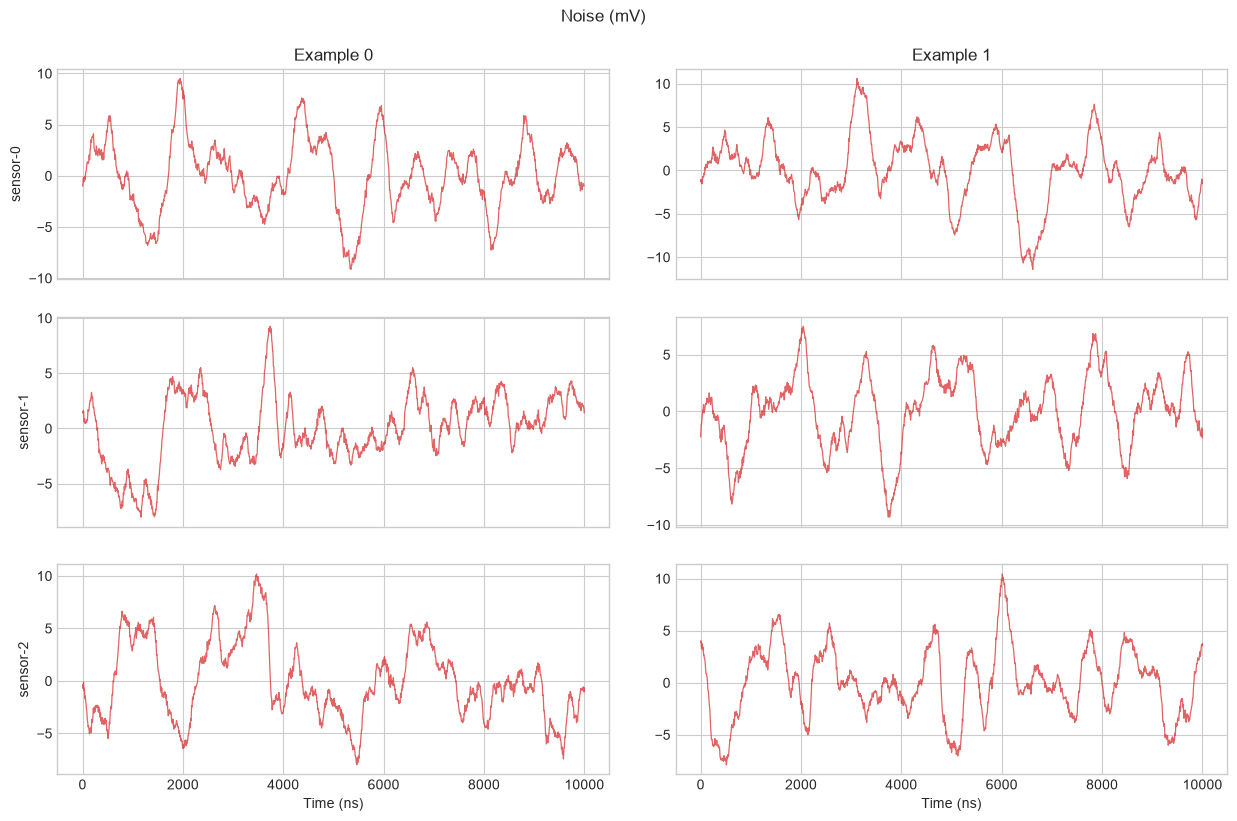

In [15]:
plot_product(
    noise_waveform,
    title="Noise (mV)",
    color="tab:red",
    step=False,
)

## AnalogWaveform

`AnalogWaveform` combines the pure response and the electronic noise. With empty `AnalogWaveformKernels`, we are simply adding together `PureWaveform` and `NoiseWaveform`.

In [16]:
analog_waveform_config = AnalogWaveformConfig(
    spec=AnalogWaveformSpec(
        axes=axes,
        device=device,
        dtype=field_dtype,
        unit=unit_registry.Unit("mV"),
    ),
    kernels=AnalogWaveformKernels(members=()),
)

analog_waveform = AnalogWaveform.create(
    sources=(
        pure_waveform,
        noise_waveform,
    ),
    config=analog_waveform_config,
)

Plotting the analog waveforms shows this superposition.

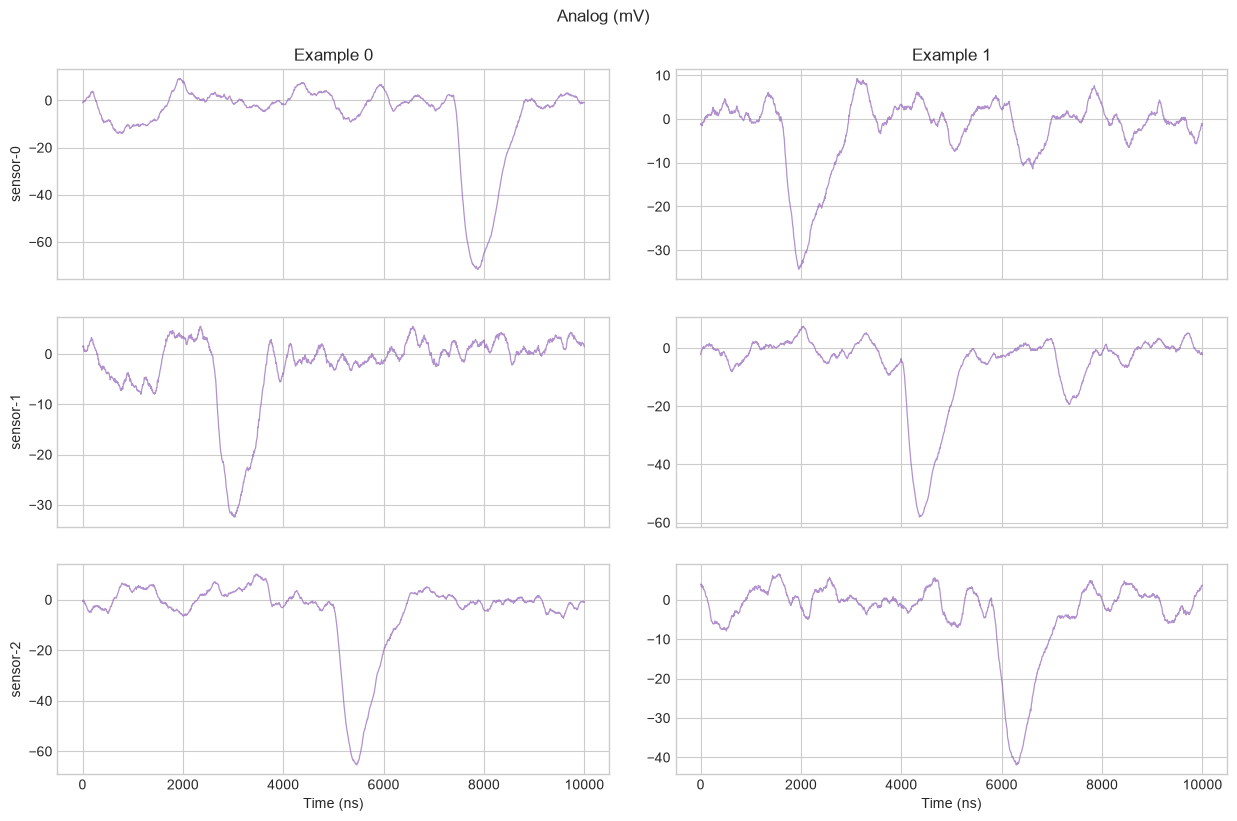

In [17]:
plot_product(
    analog_waveform,
    title="Analog (mV)",
    color="tab:purple",
    step=False,
)

## DigitizedWaveform

Four scalar tensors hold the illustrative bit depth, input interval, and linear gain. The -80 mV to 20 mV interval keeps the familiar pulse visible without universal rail clipping; these values are a demo choice, not calibration.

In [18]:
bit_depth_value = torch.tensor(12, dtype=torch.int16, device=device)
input_minimum_value = torch.tensor(
    -80.0, dtype=field_dtype, device=device
)
input_maximum_value = torch.tensor(
    20.0, dtype=field_dtype, device=device
)
analog_gain_value = torch.tensor(
    1.0, dtype=field_dtype, device=device
)

We prepare each tensor as a Kernel. `DigitizedWaveform` applies these Kernels to `AnalogWaveform` to simulate the effects of a digitizer.

In [19]:
bit_depth = BitDepth(
    tensor=bit_depth_value,
    spec=BitDepthSpec(
        conditioning_axes=(),
        operation_axes=(),
        device=device,
        dtype=torch.int16,
    ),
)

input_minimum = InputMinimum(
    tensor=input_minimum_value,
    spec=InputMinimumSpec(
        conditioning_axes=(),
        operation_axes=(),
        device=device,
        dtype=field_dtype,
        unit=unit_registry.Unit("mV"),
    ),
)

input_maximum = InputMaximum(
    tensor=input_maximum_value,
    spec=InputMaximumSpec(
        conditioning_axes=(),
        operation_axes=(),
        device=device,
        dtype=field_dtype,
        unit=unit_registry.Unit("mV"),
    ),
)

analog_gain = AnalogGain(
    tensor=analog_gain_value,
    spec=AnalogGainSpec(
        conditioning_axes=(),
        operation_axes=(),
        device=device,
        dtype=field_dtype,
        unit=unit_registry.Unit(""),
    ),
)

digitized_waveform_config = DigitizedWaveformConfig(
    spec=DigitizedWaveformSpec(
        axes=axes,
        device=device,
        dtype=torch.int32,
        unit=unit_registry.Unit(""),
    ),
    kernels=DigitizedWaveformKernels(
        members=(
            bit_depth,
            input_minimum,
            input_maximum,
            analog_gain,
        ),
    ),
)

digitized_waveform = DigitizedWaveform.create(
    sources=(analog_waveform,),
    config=digitized_waveform_config,
)

The digitized step view shows the same analog signals as integer ADC codes. The selected illustrative interval keeps the waveforms away from both rails.

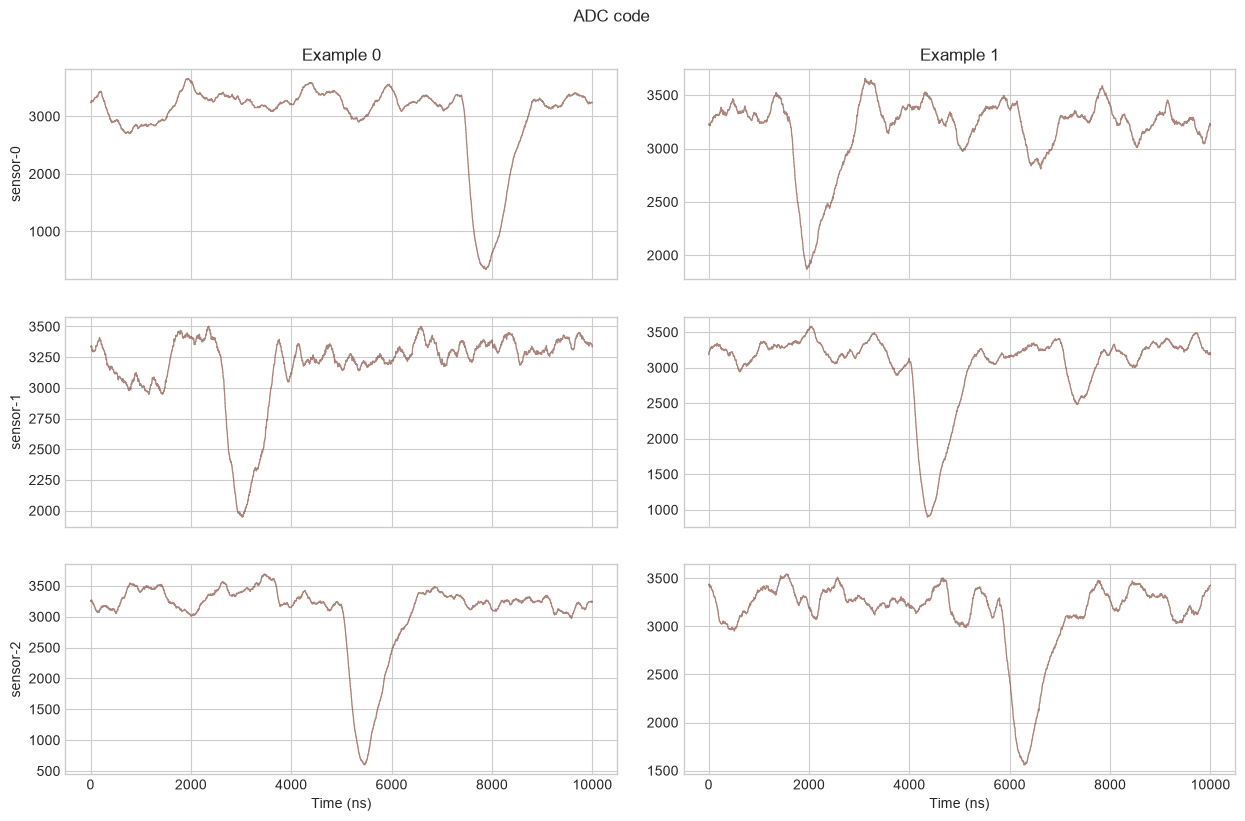

In [20]:
plot_product(
    digitized_waveform,
    title="ADC code",
    color="tab:brown",
    step=True,
)

## EncodedWaveform

We prepare scalar tensors for five ZLE settings: raw-ZLE trigger, release, time-over, and padding policy.

In [21]:
trigger_threshold_value = torch.tensor(
    2500, dtype=torch.int64, device=device
)
release_threshold_value = torch.tensor(
    2800, dtype=torch.int64, device=device
)
required_time_over_value = torch.tensor(
    3, dtype=torch.int64, device=device
)
pre_trigger_value = torch.tensor(
    25, dtype=torch.int64, device=device
)
post_trigger_value = torch.tensor(
    50, dtype=torch.int64, device=device
)

`EncodedWaveform` applies these ZLE settings to `DigitizedWaveform`.

In [22]:
trigger_threshold_code = TriggerThresholdCode(
    tensor=trigger_threshold_value,
    spec=TriggerThresholdCodeSpec(
        conditioning_axes=(),
        operation_axes=(),
        device=device,
        dtype=torch.int64,
    ),
)
release_threshold_code = ReleaseThresholdCode(
    tensor=release_threshold_value,
    spec=ReleaseThresholdCodeSpec(
        conditioning_axes=(),
        operation_axes=(),
        device=device,
        dtype=torch.int64,
    ),
)
required_time_over_samples = RequiredTimeOverSamples(
    tensor=required_time_over_value,
    spec=RequiredTimeOverSamplesSpec(
        conditioning_axes=(),
        operation_axes=(),
        device=device,
        dtype=torch.int64,
    ),
)
pre_trigger_samples = PreTriggerSamples(
    tensor=pre_trigger_value,
    spec=PreTriggerSamplesSpec(
        conditioning_axes=(),
        operation_axes=(),
        device=device,
        dtype=torch.int64,
    ),
)
post_trigger_samples = PostTriggerSamples(
    tensor=post_trigger_value,
    spec=PostTriggerSamplesSpec(
        conditioning_axes=(),
        operation_axes=(),
        device=device,
        dtype=torch.int64,
    ),
)

encoded_waveform_config = EncodedWaveformConfig(
    spec=EncodedWaveformSpec(
        axes=axes,
        device=device,
        dtype=torch.int32,
        unit=unit_registry.Unit(""),
        suppression_code=-1,
    ),
    kernels=EncodedWaveformKernels(
        members=(
            trigger_threshold_code,
            release_threshold_code,
            required_time_over_samples,
            pre_trigger_samples,
            post_trigger_samples,
        ),
    ),
)

encoded_waveform = EncodedWaveform.create(
    sources=(digitized_waveform,),
    config=encoded_waveform_config,
)

When we plot `EncodedWaveform`, we see that only the pulse regions survive ZLE processing; noisy baseline regions are suppressed.

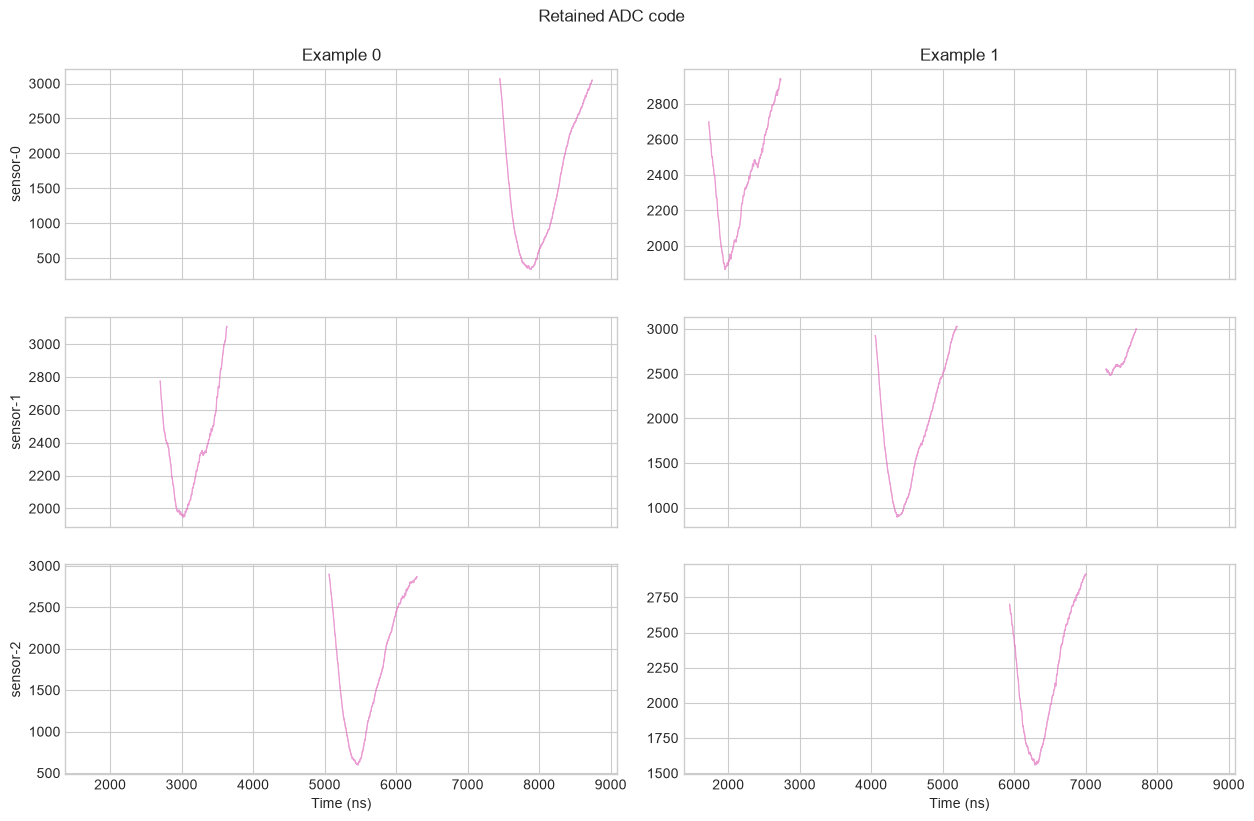

In [23]:
plot_product(
    encoded_waveform,
    title="Retained ADC code",
    color="tab:pink",
    step=True,
    suppression_code=encoded_waveform.spec.suppression_code,
)

As demonstrated by the assertions below, each Product has the same `(example, channel, time)` shape. The explicit Example and Channel dimensions let tensor backends process all six lanes together.

In [24]:
expected_shape = tuple(axis.size for axis in axes)

assert photoelectrons.tensor.shape == expected_shape
assert charge.tensor.shape == expected_shape
assert pure_waveform.tensor.shape == expected_shape
assert noise_waveform.tensor.shape == expected_shape
assert analog_waveform.tensor.shape == expected_shape
assert digitized_waveform.tensor.shape == expected_shape
assert encoded_waveform.tensor.shape == expected_shape